=================AVERAGE AFFORDABILITY BY FACILITY TYPE=================
               Procedure.Heart Attack.Cost  Procedure.Heart Failure.Cost  \
Facility.Type                                                              
Government                     6027.008459                   9596.105263   
Unknown                       11023.496047                  11524.867589   
Private                       12721.279115                  13049.343118   
Proprietary                   13133.129397                  12487.017588   
Church                        16265.768293                  14869.365854   

               Procedure.Pneumonia.Cost  
Facility.Type                            
Government                 13625.069549  
Unknown                    13359.776680  
Private                    15261.036092  
Proprietary                14268.724874  
Church                     16665.143293  

==================================EQUITY BY FACILITY TYPE=====================================
    

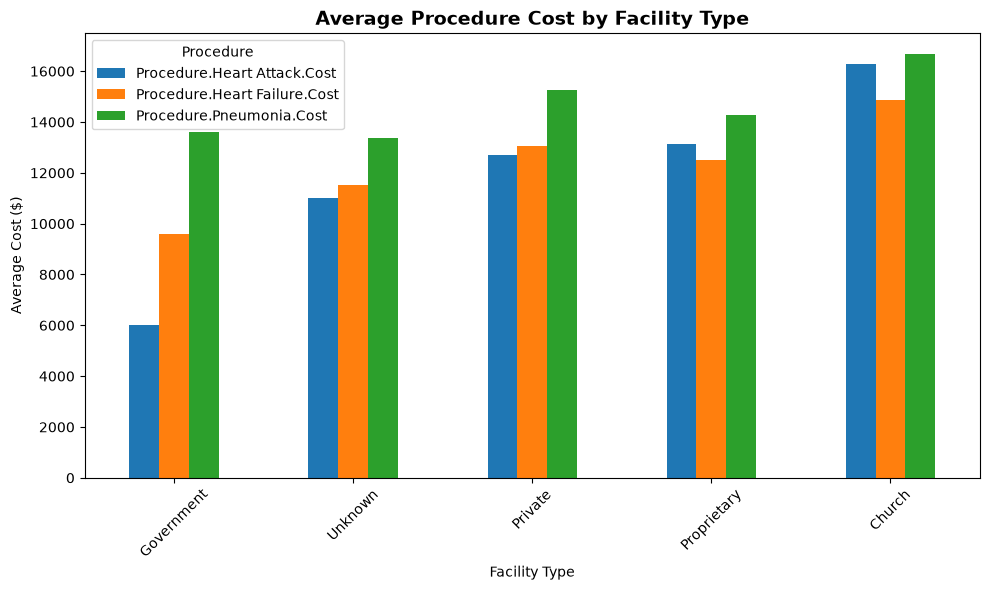

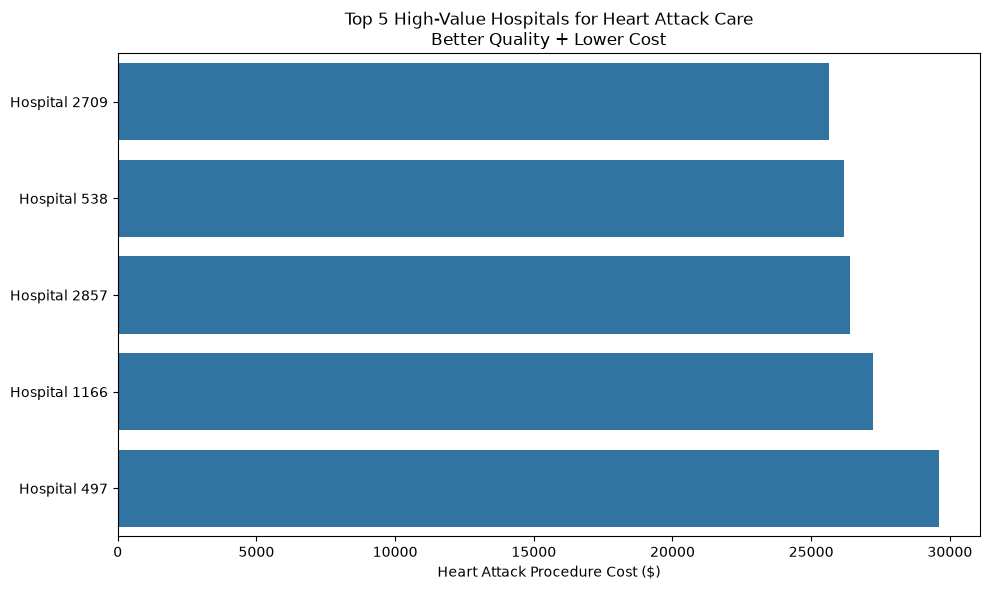

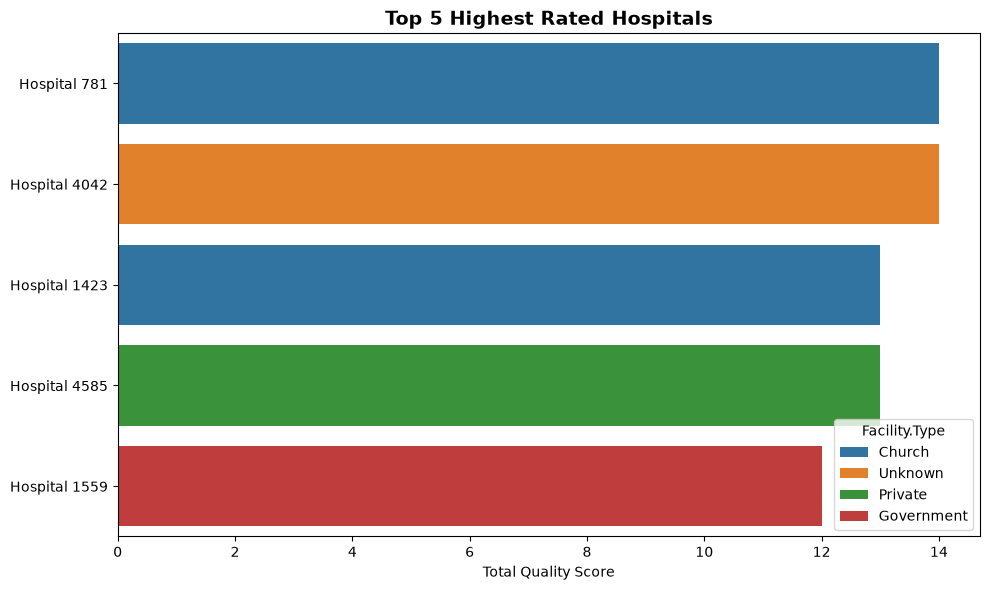

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("hospitals.csv")
cols = ['Facility.Name', 'Facility.Type', 'Rating.Overall', 'Rating.Mortality', 'Rating.Safety', 'Rating.Readmission', 'Rating.Experience', 'Rating.Effectiveness', 'Rating.Timeliness', 'Rating.Imaging', 'Procedure.Heart Attack.Cost', 'Procedure.Heart Attack.Quality', 'Procedure.Heart Attack.Value', 'Procedure.Heart Failure.Cost', 'Procedure.Heart Failure.Quality', 'Procedure.Heart Failure.Value', 'Procedure.Pneumonia.Cost', 'Procedure.Pneumonia.Quality', 'Procedure.Pneumonia.Value']
df = df[cols].copy()
df.replace(r'\.\.+', pd.NA, regex=True, inplace=True)
df.replace(r'[<>](\d+)', r'\1', regex=True, inplace=True)
df.replace(',', '', regex=True)
nums = ['Rating.Overall', 'Procedure.Heart Attack.Cost', 'Procedure.Heart Failure.Cost', 'Procedure.Pneumonia.Cost']
df[nums] = df[nums].apply(pd.to_numeric, errors='coerce')
affordable_hosp = df.groupby('Facility.Type')[['Procedure.Heart Attack.Cost', 'Procedure.Heart Failure.Cost', 'Procedure.Pneumonia.Cost']].mean().sort_values(by = ['Procedure.Heart Attack.Cost', 'Procedure.Heart Failure.Cost', 'Procedure.Pneumonia.Cost'], ascending = [True, True, True])
poor_quality_hospitals = df[(df['Procedure.Heart Attack.Quality'] == 'Worse') & (df['Procedure.Heart Failure.Quality'] == 'Worse') & (df['Procedure.Pneumonia.Quality'] == 'Worse')]
ha_v_hosp = df[(df['Procedure.Heart Attack.Value'] == 'Higher') & (df['Procedure.Heart Attack.Quality'] == 'Better')].sort_values('Procedure.Heart Attack.Cost').head(5) # ha_v_hosp stands for Heart Attack High Value Hospitals
hf_v_hosp = df[(df['Procedure.Heart Failure.Value'] == 'Higher') & (df['Procedure.Heart Failure.Quality'] == 'Better')].sort_values('Procedure.Heart Failure.Cost').head(5)   # hf_v_hosp stands for Heart Failure High Value Hospitals
hp_v_hosp = df[(df['Procedure.Pneumonia.Value'] == 'Higher') & (df['Procedure.Pneumonia.Quality'] == 'Better')].sort_values('Procedure.Pneumonia.Cost').head(5)    # hp_v_hosp stands for Pneumonia High Value Hospitals
la_v_hosp = df[(df['Procedure.Heart Attack.Value'] == 'Lower') & (df['Procedure.Heart Attack.Quality'] == 'Worse')].sort_values('Procedure.Heart Attack.Cost').head(5)  # la_v_hosp stands for Heart Attack Low Value Hospitals
lf_v_hosp = df[(df['Procedure.Heart Failure.Value'] == 'Lower') & (df['Procedure.Heart Failure.Quality'] == 'Worse')].sort_values('Procedure.Heart Failure.Cost').head(5)  # lf_v_hosp stands for Heart Failure Low Value Hospitals
lp_v_hosp = df[(df['Procedure.Pneumonia.Value'] == 'Lower') & (df['Procedure.Pneumonia.Quality'] == 'Worse')].sort_values('Procedure.Pneumonia.Cost').head(5)     # lp_v_hosp stands for Pneumonia Low Value Hospitals
unsafe_hosp = df[(df['Rating.Mortality'] == 'Above') & (df['Rating.Safety'] == 'Below') & (df['Rating.Readmission'] == 'Above')].sort_values('Rating.Overall', ascending=True).head(5)
rating_cols = ['Rating.Mortality', 'Rating.Safety', 'Rating.Readmission', 'Rating.Experience', 'Rating.Effectiveness', 'Rating.Timeliness', 'Rating.Imaging']
df[rating_cols] = df[rating_cols].replace({'Above': 2, 'Same': 1, 'Below': 0, 'None': pd.NA})
df['Total_score'] = df[rating_cols].sum(axis=1, skipna=True)
df['Above_count'] = df[rating_cols].eq(2).sum(axis=1)
top5 = df.sort_values(['Total_score', 'Above_count'], ascending=[False, False]).head(5)
equity = df.groupby('Facility.Type').agg(Avg_score =('Total_score', 'mean'), Avg_cost_Heart_Attack=('Procedure.Heart Attack.Cost', 'mean'), Avg_cost_Heart_Failure=('Procedure.Heart Failure.Cost', 'mean'),Avg_cost_Pneumonia=('Procedure.Pneumonia.Cost', 'mean'), Hospital_count=('Facility.Name', 'count')).sort_values('Avg_score',ascending=False)


print("=================AVERAGE AFFORDABILITY BY FACILITY TYPE=================")
print(affordable_hosp)
print('')
print("==================================EQUITY BY FACILITY TYPE=====================================")
print(equity)
print('')
print("===============================TOP RATED HOSPITALS============================")
print(top5[['Facility.Name', 'Facility.Type', 'Total_score', 'Above_count'] + rating_cols])
print('')
print("==========================ALERT UNSAFE HOSPITALS/ INTERVENTION NEEED=============================")
print(unsafe_hosp[['Facility.Name', 'Facility.Type', 'Rating.Mortality', 'Rating.Safety', 'Rating.Readmission','Rating.Overall']])
print('')
print("=====================POOR QUALITY HOSPITALS=====================================")
print(poor_quality_hospitals[['Facility.Name', 'Facility.Type', 'Procedure.Heart Attack.Quality','Procedure.Heart Failure.Quality', 'Procedure.Pneumonia.Quality']])
print('')
print("=================HIGH VALUE HOSPITALS AND THEIR CHARGES (DISEASE SPECIFIC)====================")
print("-------HEART ATTACK-------")
print(ha_v_hosp[['Facility.Name', 'Facility.Type', 'Procedure.Heart Attack.Cost', 'Procedure.Heart Attack.Quality', 'Procedure.Heart Attack.Value']])
print("-------HEART FAILURE------")
print(hf_v_hosp[['Facility.Name', 'Facility.Type', 'Procedure.Heart Failure.Cost', 'Procedure.Heart Failure.Quality', 'Procedure.Heart Failure.Value']])
print("-------PNEUMIONIA---------")
print(hp_v_hosp[['Facility.Name', 'Facility.Type', 'Procedure.Pneumonia.Cost', 'Procedure.Pneumonia.Quality', 'Procedure.Pneumonia.Value']])
print('')
print("=================LOW VALUE HOSPITALS AND THEIR CHARGES (DISEASE SPECIFIC)====================")
print("-------HEART ATTACK-------")
print(la_v_hosp[['Facility.Name', 'Facility.Type', 'Procedure.Heart Attack.Cost', 'Procedure.Heart Attack.Quality', 'Procedure.Heart Attack.Value']])
print("-------HEART FAILURE------")
print(lf_v_hosp[['Facility.Name', 'Facility.Type', 'Procedure.Heart Failure.Cost', 'Procedure.Heart Failure.Quality', 'Procedure.Heart Failure.Value']])
print("-------PNEUMIONIA---------")
print(lp_v_hosp[['Facility.Name', 'Facility.Type', 'Procedure.Pneumonia.Cost', 'Procedure.Pneumonia.Quality', 'Procedure.Pneumonia.Value']])
affordable_hosp.plot(kind='bar', figsize=(10,6))
plt.title('Average Procedure Cost by Facility Type', fontsize=14, fontweight='bold')
plt.ylabel('Average Cost ($)')
plt.xlabel('Facility Type')
plt.xticks(rotation=45)
plt.legend(title='Procedure')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
sns.barplot(data=ha_v_hosp, x='Procedure.Heart Attack.Cost', y='Facility.Name')
plt.title('Top 5 High-Value Hospitals for Heart Attack Care\nBetter Quality + Lower Cost', fontsize=12)
plt.xlabel('Heart Attack Procedure Cost ($)')
plt.ylabel('')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
sns.barplot(data=top5, x='Total_score', y='Facility.Name', hue='Facility.Type', dodge=False)
plt.title('Top 5 Highest Rated Hospitals', fontsize=14, fontweight='bold')
plt.xlabel('Total Quality Score')
plt.ylabel('')
plt.tight_layout()
plt.show()
